Hikyuu 交互式工具示例
==============

1、引入交互式工具
-----------------
需从hikyuu.interactive引入，而不是直接从hikyuu库中引入（hikyuu是一个库，可用于编制其他的工具，而hikyuu.interactive是基于hikyuu库实现的交互式探索工具）

In [1]:
#%matplotlib inline
%time from hikyuu.interactive import *
#use_draw_engine('echarts') #use_draw_engine('matplotlib')  #the default is 'matplotlib' drawing

Initialize hikyuu_2.8.2_202609250345_RELEASE_macosx_arm64 ...
2026-09-25 13:36:26.307 [HKU-I] - current python version: 3.13.12 (main.cpp:77)


2026-09-25 13:36:27,740 [INFO] runing in interactive session [<module>] (/Users/fasiondog/workspace/hikyuu/hikyuu/__init__.py:149) [hikyuu::hku_info]
2026-09-25 13:36:27,741 [INFO] running in jupyter [<module>] (/Users/fasiondog/workspace/hikyuu/hikyuu/__init__.py:156) [hikyuu::hku_info]


2026-09-25 13:36:27.745 [HKU-I] - 插件路径: /Users/fasiondog/workspace/hku_plugin/hikyuu_plugin (StockManager.cpp:124)
2026-09-25 13:36:27.783 [HKU-I] - Using CLICKHOUSE BaseInfoDriver (BaseInfoDriver.cpp:56)
2026-09-25 13:36:27.816 [HKU-I] - 加载市场信息…… (StockManager.cpp:1050)
2026-09-25 13:36:27.832 [HKU-I] - 加载证券类型信息…… (StockManager.cpp:1067)
2026-09-25 13:36:27.842 [HKU-I] - 加载证券信息…… (StockManager.cpp:948)
2026-09-25 13:36:27.984 [HKU-I] - 加载权息数据…… (StockManager.cpp:1170)
2026-09-25 13:36:28.177 [HKU-I] - 加载板块信息…… (StockManager.cpp:214)
2026-09-25 13:36:28.353 [HKU-I] - 加载K线数据…… (StockManager.cpp:221)
2026-09-25 13:36:28.353 [HKU-I] - 预加载 day K线数据至缓存 (最大数量: 100000)! (StockManager.cpp:395)
2026-09-25 13:36:28.353 [HKU-I] - 0.56 秒数据加载完毕. (StockManager.cpp:231)
CPU times: user 2.31 s, sys: 194 ms, total: 2.51 s
Wall time: 3.29 s


2、创建交易系统并运行
--------------------

In [2]:
# Create a simulated trading account for backtesting with an initial capital of 300,000
my_tm = crtTM(init_cash = 300000)

# Create the signal generator (the 5-day EMA as the fast line and the 10-day EMA of the 5-day EMA itself as the slow line; buy when the fast line crosses the slow line upward, and sell otherwise)
my_sg = SG_Flex(EMA(C, n=5), slow_n=10)

# Fixedly buy 1000 shares each time
my_mm = MM_FixedCount(1000)

# Create the trading system and run it
sys = SYS_Simple(tm = my_tm, sg = my_sg, mm = my_mm)
sys.run(sm['sz000001'], Query(-150))

3、绘制曲线观察
---------------

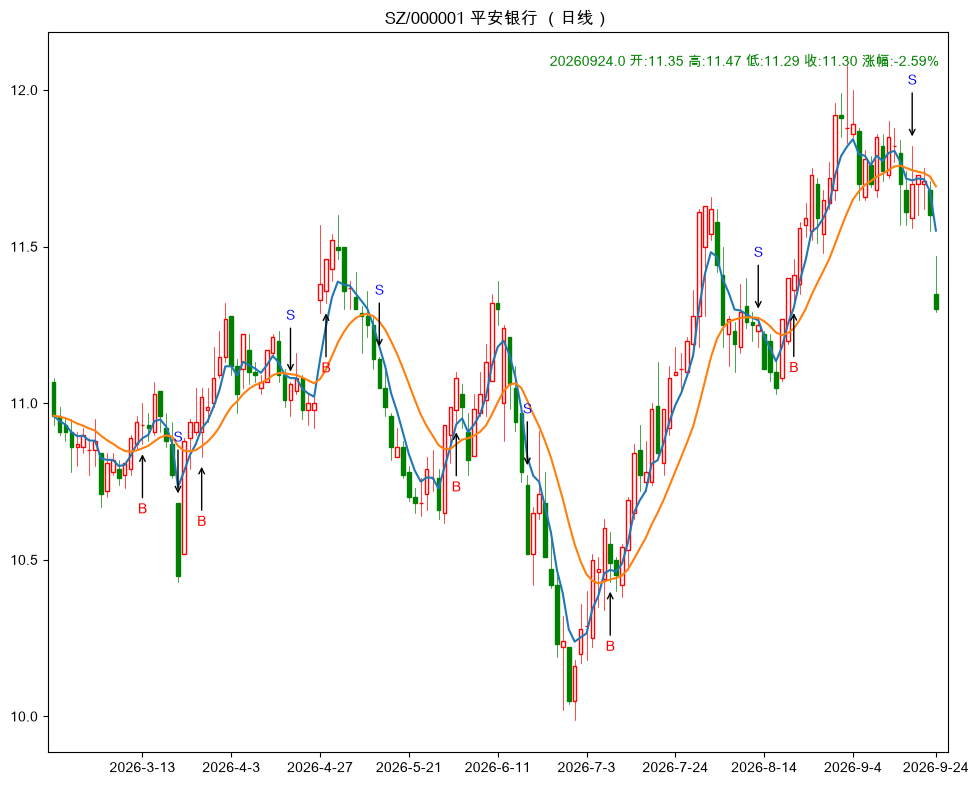

In [3]:
# Draw the system signals
sys.plot()

k = sm['sz000001'].get_kdata(Query(-150))
c = CLOSE(k)
fast = EMA(c, 5)
slow = EMA(fast, 10)

# Draw the signal generator using two indicators
fast.plot(new=False)
slow.plot(new=False)

4、绘制资金收益曲线
---------------------

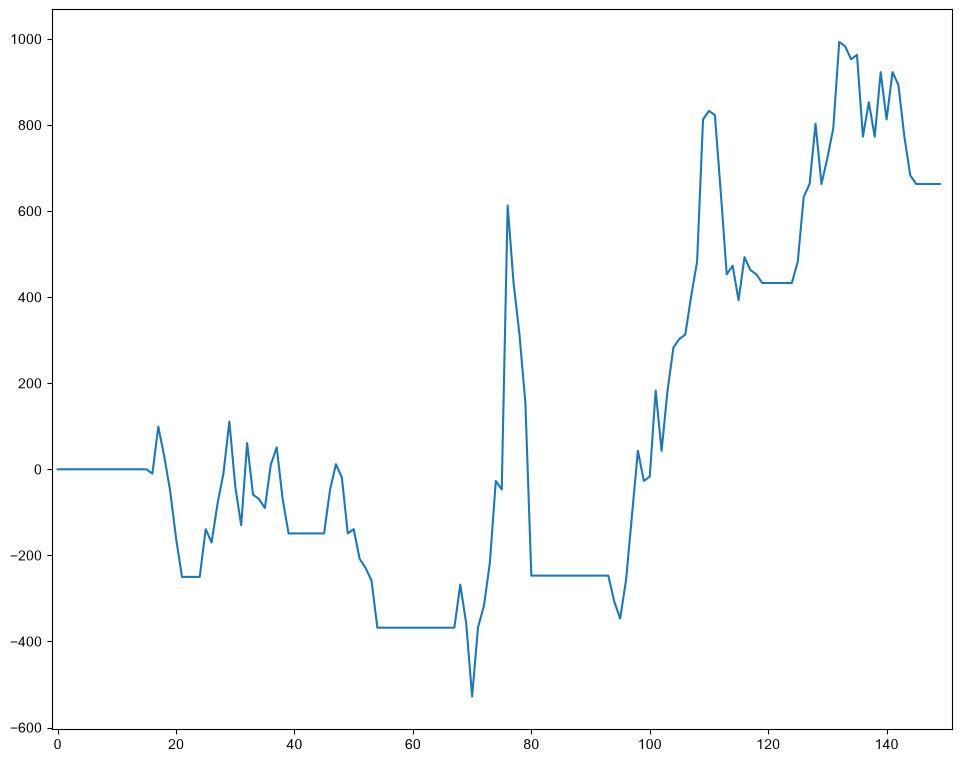

In [4]:
# Draw the equity return curve
x = my_tm.get_profit_curve(k.get_datetime_list(), Query.DAY)
x = PRICELIST(x)
x.plot()

5、回测统计报告
----------------------

In [5]:
# Backtest statistics
from datetime import datetime

per = my_tm.get_performance()
print(per.to_df())


                                    name          value
0                Account Initial Capital  300000.000000
1               Total Invested Principal  300000.000000
2                  Total Invested Assets       0.000000
3                    Total Borrowed Cash       0.000000
4                  Total Borrowed Assets       0.000000
5                        Total Dividends     360.000000
6                           Cash Balance  300663.000000
7                Open Position Net Value       0.000000
8                   Current Total Assets  300663.000000
9            Total Cost of Closed Trades       0.000000
10     Total Net Profit of Closed Trades     663.000000
11            Max Cash Usage per Trade %       3.788215
12            Avg Cash Usage per Trade %       3.672642
13        Open Position Account Return %       0.221000
14         Closed Trade Account Return %       0.221000
15                        Account CAGR %       0.409853
16           Account Avg Annual Return %       0

6、关于性能
---------------

经常有人问到性能问题，下面这段的代码使用之前的系统示例，遍历指定板块的所有股票，计算他们的“盈利交易比例%”（即胜率）。

In [10]:
def test_func(stock, query):
    """Calculate the win rate of the system strategy for the given stock，the system strategy is the previous simple double-moving-average cross system (fixedly buying 100 shares each time)
    """
    # Create a simulated trading account for backtesting with an initial capital of 300,000
    my_tm = crtTM(init_cash = 1000000)

    # Create the signal generator (the 5-day EMA as the fast line and the 10-day EMA of the 5-day EMA itself as the slow line; buy when the fast line crosses the slow line upward, and sell otherwise)
    my_sg = SG_Flex(EMA(C, n=5), slow_n=10)

    # Fixedly buy 1000 shares each time
    my_mm = MM_FixedCount(100)

    # Create the trading system and run it
    sys = SYS_Simple(tm = my_tm, sg = my_sg, mm = my_mm)
    sys.run(stock, query)
    
    per = my_tm.get_performance(ext=False)
    return per["Win Rate %"]

def total_func(blk, query):
    """Traverse all the stocks of the specified block and calculate the system win rate"""
    result = {}
    for s in blk:
        if s.valid and s.type != constant.STOCKTYPE_INDEX:
            result[s.name] = test_func(s, query)
    return result

遍历所有当前有效且并非指数的证券。下面是我的机器执行结果，共计算4151支证券，最近500个交易日，共耗时2.89秒。机器配置：Intel i7-4700HQ 2.G。

In [11]:
# Wait until all the data is loaded before testing the subsequent actual calculation performance (it is not needed in actual use; otherwise the test time includes the first data loading time)
import time
while not sm.data_ready:
    time.sleep(0.5)

In [12]:
%time a = total_func(blocka, Query(-500))
print(f"Number of securities calculated: {len(a)}")

CPU times: user 549 ms, sys: 11.3 ms, total: 560 ms
Wall time: 558 ms
Number of securities calculated: 3543


In [13]:
# 7000+ stocks over 10 years, 5~10x faster than vectorBT
%time a = total_func(blocka, Query(Datetime(20150101), Datetime(20260101)))
print(f"Number of securities calculated: {len(a)}")

CPU times: user 2.16 s, sys: 39.7 ms, total: 2.2 s
Wall time: 2.2 s
Number of securities calculated: 3543
